# MLOps Pipeline for Hospital Readmission Classification using the UCI Diabetes Dataset

This project implements an end-to-end MLOps pipeline for predicting hospital readmission risk using the UCI Diabetes 130-US Hospitals dataset. The objective is to build a reliable machine learning classification system that identifies whether a patient is likely to be readmitted within 30 days based on historical clinical records.

The dataset contains over 100,000 patient records with 47 features, including demographic information, diagnoses, medication history, and hospital visit details. It presents real-world challenges such as missing values in multiple formats, high-cardinality categorical variables, and significant class imbalance.

The pipeline covers data ingestion, preprocessing, feature engineering, model training, and evaluation using appropriate metrics such as ROC-AUC, precision, and recall. The project is structured with an MLOps mindset to support reproducibility, scalability, and deployment readiness in a healthcare environment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("diabetic_data.csv", na_values = "?")
data.sample(10)

C:\Users\HomePC\AppData\Local\Temp\ipykernel_26588\1229332509.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("diabetic_data.csv", na_values = "?")


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
100667,429073430,70177707,Caucasian,Female,[70-80),NaN,1,3,7,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
30273,97977084,12720501,NaN,Female,[60-70),NaN,2,1,1,5,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
59260,166889346,98754759,Caucasian,Female,[30-40),NaN,1,1,7,4,...,No,Up,No,No,No,No,No,Ch,Yes,NO
59329,166998696,43285095,Caucasian,Female,[90-100),NaN,1,23,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,<30
44941,138735828,113619348,Caucasian,Male,[70-80),NaN,1,11,7,10,...,No,No,No,No,No,No,No,No,No,NO
40816,126613752,43446681,Caucasian,Male,[90-100),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,>30
67741,190435902,81509760,Caucasian,Female,[80-90),NaN,2,11,7,2,...,No,Steady,No,No,No,No,No,No,Yes,NO
69718,198707658,40948776,Caucasian,Male,[40-50),NaN,1,6,7,11,...,No,Down,No,No,No,No,No,Ch,Yes,NO
44305,136593888,52810641,AfricanAmerican,Male,[50-60),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
80523,248395188,97354656,Caucasian,Male,[80-90),NaN,2,1,7,4,...,No,No,No,No,No,No,No,No,Yes,NO


In [3]:
data.shape

(101766, 50)

In [4]:
missing_data = data.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_data / len(data)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing_data,
    'missing_percent': missing_percent
})

missing_df.head(10)

,missing_count,missing_percent
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636
encounter_id,0,0.000000


The dataset contains 101,766 patient encounters and 50 features. It is a real-world clinical dataset characterized by significant missing data, particularly in laboratory and specialty-related features. The level of missingness varies across features, requiring a combination of feature removal and targeted imputation strategies to ensure data quality for modeling.

Columns with extremely high levels of missing data (typically above 80%) were dropped from the dataset as part of the data preprocessing stage. These features lacked sufficient information density to support reliable statistical imputation and would likely introduce noise or bias if retained. Removing them helps improve data quality, reduces dimensionality, and ensures the machine learning model is trained on more meaningful and informative features.

High-cardinality categorical variables such as medical_specialty and payer_code were reduced by grouping infrequent categories into an 'other' class. This reduces dimensionality, prevents sparsity during encoding, and improves model generalization.

In [5]:
data.drop(columns=['weight', 'max_glu_serum', 'A1Cresult'], inplace=True)


data['medical_specialty'] = data['medical_specialty'].fillna('missing')
data['payer_code'] = data['payer_code'].fillna('missing')

threshold = 0.01

top_specialties = data['medical_specialty'].value_counts(normalize=True)
top_specialties = top_specialties[top_specialties > threshold].index
data['medical_specialty'] = data['medical_specialty'].apply(
    lambda x: x if x in top_specialties else 'other'
)

top_payers = data['payer_code'].value_counts(normalize=True)
top_payers = top_payers[top_payers > threshold].index
data['payer_code'] = data['payer_code'].apply(
    lambda x: x if x in top_payers else 'other'
)

In [6]:
data[['medical_specialty', 'payer_code']].isnull().sum()

medical_specialty    0
payer_code           0
dtype: int64

In [7]:
data['medical_specialty'].value_counts().head(10)

medical_specialty
missing                       49949
InternalMedicine              14635
other                          8340
Emergency/Trauma               7565
Family/GeneralPractice         7440
Cardiology                     5352
Surgery-General                3099
Nephrology                     1613
Orthopedics                    1400
Orthopedics-Reconstructive     1233
Name: count, dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
data['readmitted'].value_counts(normalize=True)

readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64

The dataset was checked for duplicate records and none were found, confirming data integrity at the row level.

The target variable (readmitted) shows a moderate class imbalance:
- NO: 53.9%
- >30: 34.9%
- <30: 11.2%

The target variable (readmitted) represents a three-class classification problem with moderate class imbalance. The minority class (<30 days readmission) is of particular clinical importance and will require evaluation metrics beyond accuracy, such as recall and F1-score.

Missing values were consistently encoded using the label 'missing' across categorical features to ensure uniform representation of incomplete data during model training.

In [10]:
data['race'] = data['race'].fillna('missing')
for col in ['diag_1', 'diag_2', 'diag_3']:
    data[col] = data[col].fillna('missing')

In [11]:
data['race'] = data['race'].replace({'AfricanAmerican': 'African American'})

In [12]:
missing_data = data.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_data / len(data)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing_data,
    'missing_percent': missing_percent
})

missing_df.head(10)

,missing_count,missing_percent
encounter_id,0,0.0
tolazamide,0,0.0
acetohexamide,0,0.0
glipizide,0,0.0
glyburide,0,0.0
tolbutamide,0,0.0
pioglitazone,0,0.0
rosiglitazone,0,0.0
acarbose,0,0.0
miglitol,0,0.0


In [13]:
data.isnull().sum().sum()

np.int64(0)

In [14]:
data.duplicated().sum()

np.int64(0)

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   admission_type_id         101766 non-null  int64 
 6   discharge_disposition_id  101766 non-null  int64 
 7   admission_source_id       101766 non-null  int64 
 8   time_in_hospital          101766 non-null  int64 
 9   payer_code                101766 non-null  object
 10  medical_specialty         101766 non-null  object
 11  num_lab_procedures        101766 non-null  int64 
 12  num_procedures            101766 non-null  int64 
 13  num_medications           101766 non-null  int64 
 14  numb

In [16]:
data.select_dtypes(include='object').nunique().sort_values()

citoglipton                   1
examide                       1
tolbutamide                   2
change                        2
metformin-pioglitazone        2
metformin-rosiglitazone       2
glimepiride-pioglitazone      2
glipizide-metformin           2
troglitazone                  2
diabetesMed                   2
acetohexamide                 2
tolazamide                    3
readmitted                    3
gender                        3
chlorpropamide                4
glipizide                     4
glyburide                     4
nateglinide                   4
pioglitazone                  4
rosiglitazone                 4
acarbose                      4
miglitol                      4
repaglinide                   4
metformin                     4
glimepiride                   4
insulin                       4
glyburide-metformin           4
race                          6
age                          10
medical_specialty            11
payer_code                   11
diag_1  

In [17]:
np.isinf(data.select_dtypes(include=['number'])).sum()

encounter_id                0
patient_nbr                 0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
number_diagnoses            0
dtype: int64

In [18]:
data.describe(include='all')

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,1.017660e+05,1.017660e+05,101766,101766,101766,101766.000000,101766.000000,101766.000000,101766.000000,101766,...,101766,101766,101766,101766,101766,101766,101766,101766,101766,101766
unique,NaN,NaN,6,3,10,NaN,NaN,NaN,NaN,11,...,1,4,4,2,2,2,2,2,2,3
top,NaN,NaN,Caucasian,Female,[70-80),NaN,NaN,NaN,NaN,missing,...,No,No,No,No,No,No,No,No,Yes,NO
freq,NaN,NaN,76099,54708,26068,NaN,NaN,NaN,NaN,40256,...,101766,47383,101060,101753,101765,101764,101765,54755,78363,54864
mean,1.652016e+08,5.433040e+07,NaN,NaN,NaN,2.024006,3.715642,5.754437,4.395987,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.026403e+08,3.869636e+07,NaN,NaN,NaN,1.445403,5.280166,4.064081,2.985108,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.252200e+04,1.350000e+02,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,8.496119e+07,2.341322e+07,NaN,NaN,NaN,1.000000,1.000000,1.000000,2.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.523890e+08,4.550514e+07,NaN,NaN,NaN,1.000000,1.000000,7.000000,4.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2.302709e+08,8.754595e+07,NaN,NaN,NaN,3.000000,4.000000,7.000000,6.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
data['readmitted'].value_counts(normalize=True)

readmitted
NO     0.539119
>30    0.349282
<30    0.111599
Name: proportion, dtype: float64

After preprocessing, the dataset contains no missing values or duplicate records. Data types are consistent across features, and categorical variables have been standardized. The dataset is now in a clean state suitable for feature engineering and model training.

Features with extremely high missing rates (greater than 80%) such as weight, max_glu_serum, and A1Cresult were removed due to insufficient data density, which would otherwise introduce noise and reduce model reliability.

With data cleaning and feature preprocessing completed, the dataset is now ready for encoding, feature transformation, and supervised machine learning model development as part of the MLOps pipeline.

In [20]:
data_mapping = pd.read_csv("IDS_mapping.csv")
data_mapping.info()
data_mapping.sample(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   admission_type_id  65 non-null     object
 1   description        62 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


,admission_type_id,description
64,24,Born outside this hospital
27,18,NaN
37,27,Discharged/transferred to a federal health car...
61,21,Unknown/Invalid
13,4,Discharged/transferred to ICF
53,12,Premature Delivery
20,11,Expired
14,5,Discharged/transferred to another type of inpa...
26,17,Discharged/transferred/referred to this instit...
22,13,Hospice / home


In [21]:
data.drop(columns=['encounter_id', 'patient_nbr'], inplace=True)

The columns 'encounter_id' and 'patient_nbr' were removed from the dataset because they are purely identifier variables with no predictive value for the target outcome. These fields do not represent clinical or behavioral attributes and therefore do not contribute meaningful signal for machine learning models.

Retaining such identifiers can lead to overfitting, where the model memorizes specific records rather than learning generalizable patterns. Removing them improves model generalization, reduces noise, and ensures the learning process focuses on clinically relevant features only.

This step is an important part of feature selection in the MLOps pipeline, ensuring that the final model is both robust and production-ready.

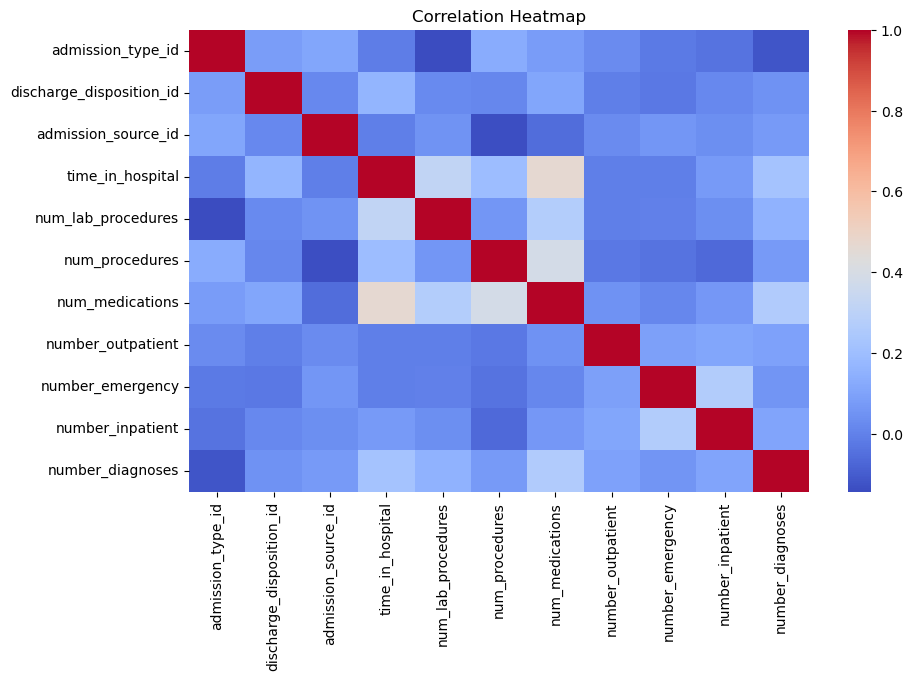

In [22]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

A correlation heatmap was used to visualize relationships between numerical clinical features. The results indicate moderate positive correlations among key healthcare utilization variables such as time in hospital, number of medications, number of procedures, and number of lab procedures. This suggests that patients with longer hospital stays tend to receive more intensive medical interventions.

No strong correlations (above 0.8) were observed between features, indicating that multicollinearity is not a concern. As a result, all numerical variables were retained for model development.

Overall, the correlation structure reflects realistic clinical behavior and supports the validity of the dataset for predictive modeling.

## Feature Engineering Preparation

With the completion of data cleaning and exploratory data analysis (EDA), the dataset is now well-structured, consistent, and free from missing or redundant values. The correlation analysis further confirmed that there are no strong multicollinearity issues among numerical features, and the observed relationships align with expected clinical patterns.

At this stage, the dataset is ready to transition into feature engineering, where raw variables will be transformed into a format suitable for machine learning models. This step is critical as it directly impacts model performance and predictive accuracy.

The next phase will involve encoding categorical variables, transforming the target variable, and creating meaningful derived features to enhance the model’s ability to learn patterns from the data.

In [23]:
def age_to_midpoint(age_range):
    age_range = age_range.strip('[)')
    low, high = age_range.split('-')
    return (int(low) + int(high)) / 2

data['age'] = data['age'].apply(age_to_midpoint)

In [24]:
data['diag_1'].head(10)

0    250.83
1       276
2       648
3         8
4       197
5       414
6       414
7       428
8       398
9       434
Name: diag_1, dtype: object

In [25]:
data['diag_1'].value_counts().head(20)

diag_1
428      6862
414      6581
786      4016
410      3614
486      3508
427      2766
491      2275
715      2151
682      2042
434      2028
780      2019
996      1967
276      1889
38       1688
250.8    1680
599      1595
584      1520
V57      1207
250.6    1183
518      1115
Name: count, dtype: int64

In [26]:
def clean_diag(diag):
    try:
        return float(diag)
    except:
        return None  # handles V, E, ?, etc.

data['diag_1_num'] = data['diag_1'].apply(clean_diag)

In [27]:
def map_diagnosis(diag):
    if diag is None:
        return 'Other'

    if 390 <= diag < 460:
        return 'Circulatory'
    elif 460 <= diag < 520:
        return 'Respiratory'
    elif 520 <= diag < 580:
        return 'Digestive'
    elif 250 <= diag < 251:
        return 'Diabetes'
    elif 800 <= diag < 1000:
        return 'Injury'
    else:
        return 'Other'

In [28]:
data['diag_1_group'] = data['diag_1_num'].apply(map_diagnosis)

In [29]:
data['diag_1_group'].value_counts()

diag_1_group
Other          36084
Circulatory    30336
Respiratory    10407
Digestive       9208
Diabetes        8757
Injury          6974
Name: count, dtype: int64

In [30]:
data['diag_2_num'] = data['diag_2'].apply(clean_diag)
data['diag_3_num'] = data['diag_3'].apply(clean_diag)

In [31]:
data['diag_2_group'] = data['diag_2_num'].apply(map_diagnosis)
data['diag_3_group'] = data['diag_3_num'].apply(map_diagnosis)

In [32]:
data['diag_2_group'].value_counts()

diag_2_group
Other          40966
Circulatory    31365
Diabetes       12794
Respiratory    10251
Digestive       3962
Injury          2428
Name: count, dtype: int64

In [33]:
data['diag_3_group'].value_counts()

diag_3_group
Other          42399
Circulatory    29918
Diabetes       17157
Respiratory     6774
Digestive       3572
Injury          1946
Name: count, dtype: int64

In [34]:
groups = ['Circulatory', 'Respiratory', 'Digestive', 'Diabetes', 'Injury']

for g in groups:
    data[f'has_{g.lower()}'] = (
        (data['diag_1_group'] == g) |
        (data['diag_2_group'] == g) |
        (data['diag_3_group'] == g)
    ).astype(int)

In [35]:
data[[f'has_{g.lower()}' for g in groups]].sum()

has_circulatory    58672
has_respiratory    22515
has_digestive      13641
has_diabetes       38024
has_injury          9969
dtype: int64

In [36]:
data = data.drop(columns=[
    'diag_1', 'diag_2', 'diag_3',
    'diag_1_num', 'diag_2_num', 'diag_3_num',
    'diag_1_group', 'diag_2_group', 'diag_3_group'
])

In [37]:
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone',
    'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin',
    'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

In [38]:
for col in medication_cols:
    print(f"{col}: {data[col].unique()}")

metformin: ['No' 'Steady' 'Up' 'Down']
repaglinide: ['No' 'Up' 'Steady' 'Down']
nateglinide: ['No' 'Steady' 'Down' 'Up']
chlorpropamide: ['No' 'Steady' 'Down' 'Up']
glimepiride: ['No' 'Steady' 'Down' 'Up']
acetohexamide: ['No' 'Steady']
glipizide: ['No' 'Steady' 'Up' 'Down']
glyburide: ['No' 'Steady' 'Up' 'Down']
tolbutamide: ['No' 'Steady']
pioglitazone: ['No' 'Steady' 'Up' 'Down']
rosiglitazone: ['No' 'Steady' 'Up' 'Down']
acarbose: ['No' 'Steady' 'Up' 'Down']
miglitol: ['No' 'Steady' 'Down' 'Up']
troglitazone: ['No' 'Steady']
tolazamide: ['No' 'Steady' 'Up']
examide: ['No']
citoglipton: ['No']
insulin: ['No' 'Up' 'Steady' 'Down']
glyburide-metformin: ['No' 'Steady' 'Down' 'Up']
glipizide-metformin: ['No' 'Steady']
glimepiride-pioglitazone: ['No' 'Steady']
metformin-rosiglitazone: ['No' 'Steady']
metformin-pioglitazone: ['No' 'Steady']


In [39]:
for col in medication_cols:
    print(f"{col}:")
    print(data[col].value_counts())
    print("-" * 40)

metformin:
metformin
No        81778
Steady    18346
Up         1067
Down        575
Name: count, dtype: int64
----------------------------------------
repaglinide:
repaglinide
No        100227
Steady      1384
Up           110
Down          45
Name: count, dtype: int64
----------------------------------------
nateglinide:
nateglinide
No        101063
Steady       668
Up            24
Down          11
Name: count, dtype: int64
----------------------------------------
chlorpropamide:
chlorpropamide
No        101680
Steady        79
Up             6
Down           1
Name: count, dtype: int64
----------------------------------------
glimepiride:
glimepiride
No        96575
Steady     4670
Up          327
Down        194
Name: count, dtype: int64
----------------------------------------
acetohexamide:
acetohexamide
No        101765
Steady         1
Name: count, dtype: int64
----------------------------------------
glipizide:
glipizide
No        89080
Steady    11356
Up          770
Down   

In [40]:
drop_cols = [
    'examide', 'citoglipton',
    'acetohexamide', 'tolbutamide', 'troglitazone',
    'glimepiride-pioglitazone',
    'metformin-pioglitazone',
    'metformin-rosiglitazone'
]

data = data.drop(columns=drop_cols)

In [41]:
mapping = {
    "No": 0,
    "Steady": 1,
    "Up": 2,
    "Down": -1
}

remaining_med_cols = [col for col in medication_cols if col not in drop_cols]

for col in remaining_med_cols:
    data[col] = data[col].map(mapping)

In [42]:
data['num_med_up'] = (data[remaining_med_cols] == 2).sum(axis=1)
data['num_med_down'] = (data[remaining_med_cols] == -1).sum(axis=1)
data['num_med_used'] = (data[remaining_med_cols] > 0).sum(axis=1)

In [43]:
data[['num_med_up', 'num_med_down', 'num_med_used']].describe()

,num_med_up,num_med_down,num_med_used
count,101766.000000,101766.000000,101766.000000
mean,0.146070,0.141373,1.038028
std,0.370902,0.356356,0.922629
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000
75%,0.000000,0.000000,2.000000
max,3.000000,3.000000,6.000000


In [44]:
data['change'] = data['change'].map({'No': 0, 'Ch': 1})
data['diabetesMed'] = data['diabetesMed'].map({'No': 0, 'Yes': 1})

In [45]:
data['readmitted'] = data['readmitted'].map({
    'NO': 0,
    '>30': 0,
    '<30': 1
})

In [46]:
data = pd.get_dummies(data, columns=['gender', 'race'], drop_first=True)

In [47]:
top_specialties = [
    'InternalMedicine',
    'Emergency/Trauma',
    'Family/GeneralPractice',
    'Cardiology',
    'Surgery-General',
    'Nephrology',
    'Orthopedics',
    'Orthopedics-Reconstructive',
    'Radiologist'
]

In [48]:
data['medical_specialty'] = data['medical_specialty'].apply(
    lambda x: x if x in top_specialties else 'Other'
)

In [49]:
data = pd.get_dummies(data, columns=['medical_specialty'], drop_first=True)

In [50]:
data = data.drop(columns=['payer_code'])

In [52]:
data = pd.get_dummies(
    data,
    columns=[
        'admission_type_id',
        'discharge_disposition_id',
        'admission_source_id'
    ],
    drop_first=True
)

In [54]:
data = data.astype({col: 'int8' for col in data.select_dtypes('bool').columns})

In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 99 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   age                                           101766 non-null  float64
 1   time_in_hospital                              101766 non-null  int64  
 2   num_lab_procedures                            101766 non-null  int64  
 3   num_procedures                                101766 non-null  int64  
 4   num_medications                               101766 non-null  int64  
 5   number_outpatient                             101766 non-null  int64  
 6   number_emergency                              101766 non-null  int64  
 7   number_inpatient                              101766 non-null  int64  
 8   number_diagnoses                              101766 non-null  int64  
 9   metformin                                     10

In [57]:
data['readmitted'].value_counts(normalize=True)

readmitted
0    0.888401
1    0.111599
Name: proportion, dtype: float64

In [59]:
from sklearn.model_selection import train_test_split

X = data.drop('readmitted', axis=1)
y = data['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)